## Aula 2: Experimentação e MVP de Modelos - Heart Disease Dataset

### Objetivos de Aprendizagem

- Realizar Análise Exploratória de Dados (EDA) completa
- Identificar e tratar anomalias, outliers e missing values
- Aplicar técnicas de preparação de dados
- Configurar e usar MLFlow para rastreamento de experimentos
- Experimentar com diferentes algoritmos e hiperparâmetros
- Comparar resultados de múltiplos experimentos
- Criar um MVP (Minimum Viable Product) de modelo

### Exercício Prático
Você trabalhará com o dataset Heart Disease da UCI Machine Learning Repository para prever a presença de doenças cardíacas. Este exercício enfatiza as técnicas essenciais de preparação de dados que todo cientista de dados deve dominar.

### 1. Configuração do Ambiente

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# basicas
import warnings
warnings.filterwarnings('ignore')

# visualizacao
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# estatistica
import scipy.stats as stats

## 2. Carregamento dos Dados
### Sobre o Dataset Heart Disease
Fonte: conjunto consolidado dos quatro datasets da UCI (Cleveland, Hungarian, Switzerland e VA Long Beach), disponibilizado no Kaggle já com alguns tratamentos de texto. O dataset original por ser encontrado em: https://archive.ics.uci.edu/dataset/45/heart+disease):

Observações: 920
Colunas: 16 (inclui metadados como id e dataset)
Alvo original: num (0–4), onde 0 = ausência de doença e 1–4 = presença em diferentes graus
Valores ausentes: presentes em múltiplos campos (ex.: trestbps, chol, thalch, exang, oldpeak, slope, ca, thal)

### Esquema das Variáveis (conforme Kaggle)
- id: identificador do paciente
- dataset: origem do caso (Cleveland, Hungarian, Switzerland, VA Long Beach)
- age: idade (anos)
- sex: sexo (Male/Female)
- cp: tipo de dor no peito (typical angina, atypical angina, non-anginal, asymptomatic)
- trestbps: pressão arterial em repouso (mmHg)
- chol: colesterol sérico (mg/dl)
- fbs: glicemia em jejum > 120 mg/dl (True/False)
- restecg: ECG em repouso (normal, st-t abnormality, lv hypertrophy)
- thalch: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício (True/False)
- oldpeak: depressão do ST induzida por exercício (unidades “ST depression”)
- slope: inclinação do segmento ST de pico (upsloping, flat, downsloping)
- ca: número de vasos principais coloridos por fluoroscopia (0–3)
- thal: estado talassêmico (normal, fixed defect, reversable defect)
- num: diagnóstico (0 = sem doença; 1–4 = presença)

In [27]:
# carregar o dataset
path = '../data/heart_disease_uci.csv'

# carregar dados
df = pd.read_csv(path)
print(f'Shape do dataset: {df.shape}')
print(f'\nPrimeiras linhas do dataset:')
df.head(10)

Shape do dataset: (920, 16)

Primeiras linhas do dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


O dataset carregado contém informações clínicas de pacientes para análise de doenças cardíacas. 

Cada linha representa um paciente, com variáveis como idade, sexo, tipo de dor no peito, pressão arterial, colesterol, resultados de exames, e o diagnóstico (coluna `num`). Algumas colunas apresentam valores ausentes, que serão tratados nas etapas seguintes. O objetivo é prever a presença de doença cardíaca a partir dessas variáveis, utilizando técnicas de análise exploratória e modelagem preditiva.

In [26]:
# informacoes gerais
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
df.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB

=== ESTATÍSTICAS DESCRITIVAS ===



,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## O que fazem df.info() e df.describe()
### df.info()

Resume a estrutura do DataFrame.
Mostra: número de linhas e colunas, nomes das colunas, contagem de valores não nulos por coluna (útil para identificar missing values), tipos de dados e uso de memória.
No contexto do dataset, ajuda a ver rapidamente onde há muitos ausentes (ex.: ca, thal, slope) e quais colunas são numéricas vs. categóricas para orientar o pré-processamento.

### df.describe()

Calcula estatísticas descritivas para colunas numéricas por padrão.
Mostra: count, mean, std, min, 25%, 50% (mediana), 75%, max.
Útil para entender escala, dispersão e possíveis outliers (ex.: valores extremos em chol, trestbps, oldpeak).
Dica: para estatísticas de colunas categóricas (como sex, cp, thal), use df.describe(include='object') ou df.describe(include='all') para obter count, unique, top e freq.

## 3. Análise Exploratória de Dados (EDA)
### 3.1 Análise de Missing Values
Objetivo: Identificar valores ausentes e entender seu padrão de distribuição

8 files de frango empanado

=== ANÁLISE DE MISSING VALUES ===

            Coluna  Missing_Count  Missing_Percentage
ca              ca            611               66.41
thal          thal            486               52.83
slope        slope            309               33.59
fbs            fbs             90                9.78
oldpeak    oldpeak             62                6.74
trestbps  trestbps             59                6.41
exang        exang             55                5.98
thalch      thalch             55                5.98
chol          chol             30                3.26
restecg    restecg              2                0.22


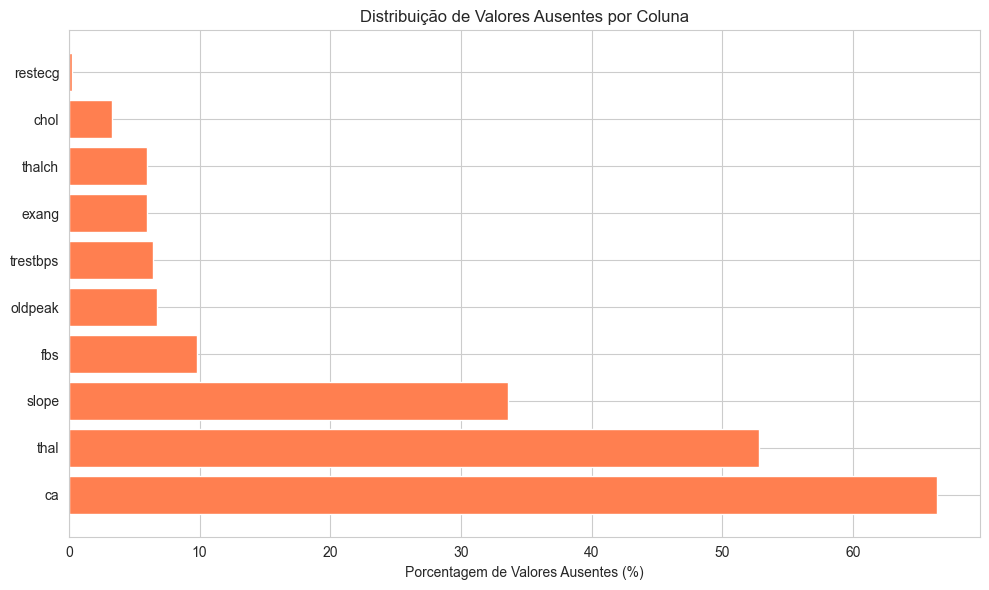

In [30]:
# Analise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
    })

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)

if len(missing_values) > 0:
    print(missing_values)

    # visualizar os missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Valores Ausentes (%)')
    plt.title('Distribuição de Valores Ausentes por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Não há valores ausentes no dataset.")

## 3.2 Análise da Variável Target
**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
1    509
0    411
Name: count, dtype: int64

Porcentagem:
Com doença: 55.33%
Sem doença: 44.67%


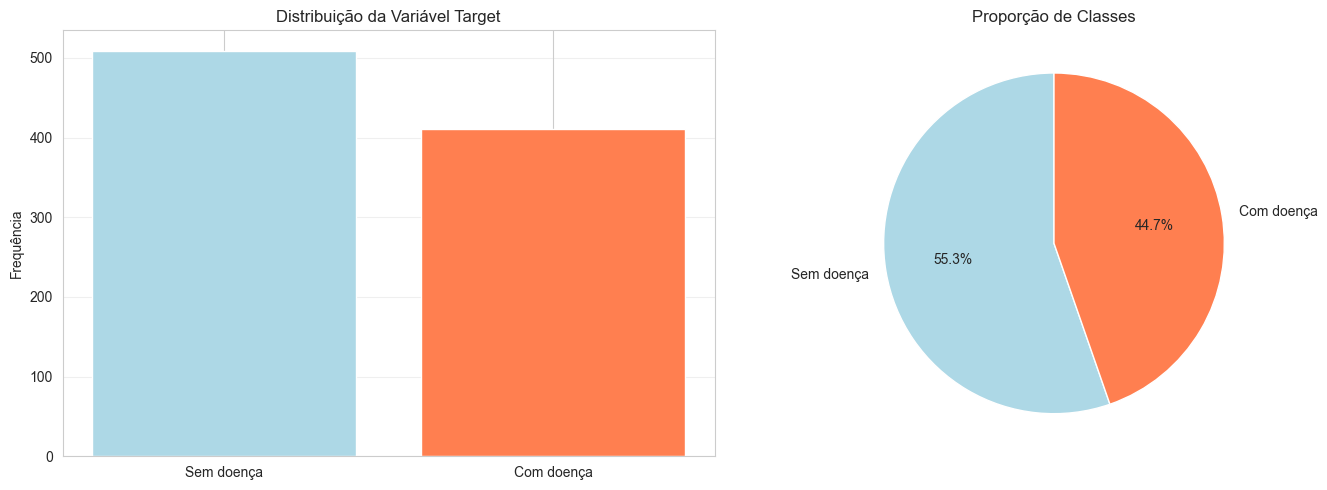

Razão entre as classes: 0.81
Dataset razoavelmente balanceado


In [38]:
## Renomear a variável ´num´para ´target´
df.rename(columns={'num': 'target'}, inplace=True)

# Converter target para binário (0 = sem doença, 1 = com doença)
# No dataset original, valores > 0 indicam presença de doença
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPorcentagem:")
for idx, pct in target_percentages.items():
    label = "Sem doença" if idx == 0 else "Com doença"
    print(f"{label}: {pct:.2f}%")

# visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grafico de barras
axes[0].bar(['Sem doença', 'Com doença'], target_counts, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# grafico de setores
axes[1].pie(target_counts.values, labels=['Sem doença', 'Com doença'],
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# verifica se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"Razão entre as classes: {ratio:.2f}")

if ratio < 0.5:
    print('Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.')
else:
    print('Dataset razoavelmente balanceado')

## 3.3 Análise de Outliers
**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**

- **Z-Score:** Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização:** Boxplots para identificação visual

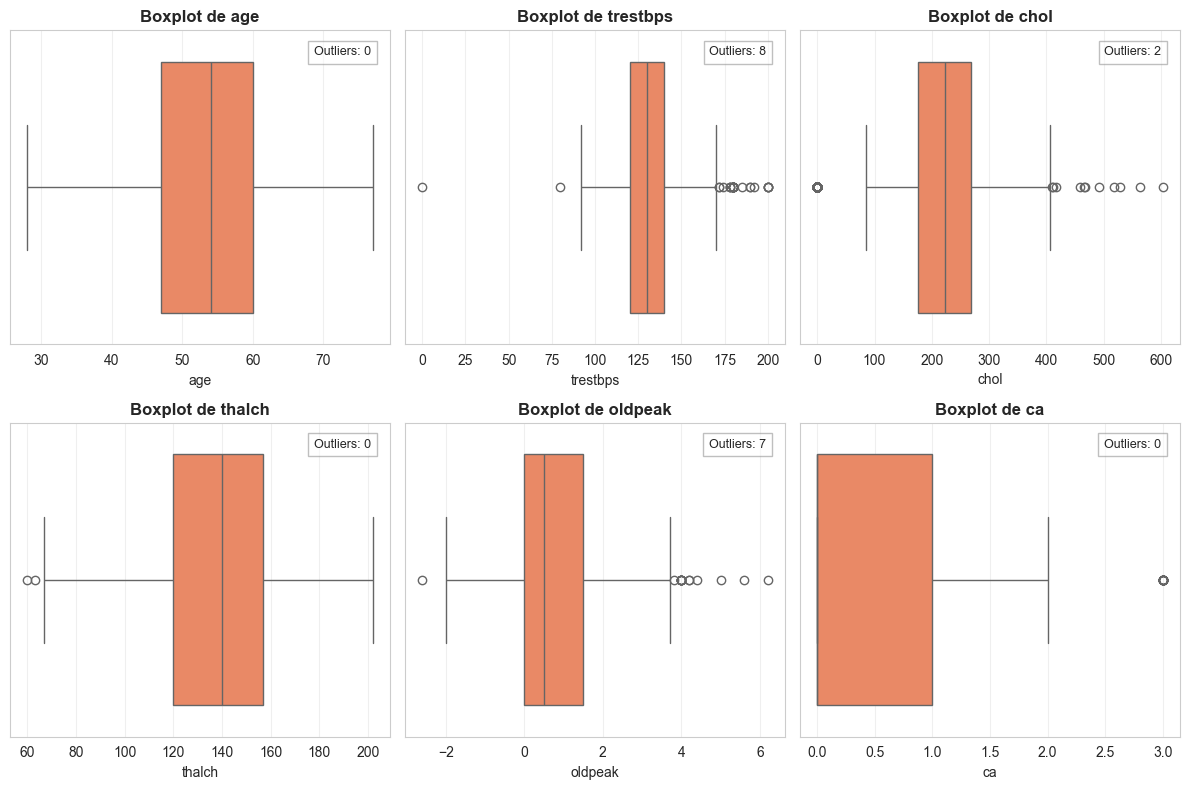

In [ ]:
# colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['id', 'target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows * 4))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot de {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[idx].transAxes,
                    fontsize=9,
                    verticalalignment='top',
                    horizontalalignment='right',
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
    
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()